# Réplication Simulations TVA - Budget 2025 : Chapitre socio-fiscal

In [1]:
import numpy as np
import pandas as pd
import os
import csv
import ast
import seaborn as sns
from matplotlib import pyplot as plt
import wquantiles 

from tqdm import tqdm
from wquantiles import quantile
from openfisca_survey_manager.utils import asof

from openfisca_france_indirect_taxation import FranceIndirectTaxationTaxBenefitSystem
from openfisca_france_indirect_taxation.surveys import SurveyScenario
from openfisca_france_indirect_taxation.utils import assets_directory, get_input_data_frame
from openfisca_france_indirect_taxation.examples.utils_example import (
    dataframe_by_group,
    df_weighted_average_grouped,
    wavg)
from openfisca_france_indirect_taxation.build_survey_data.utils import weighted_sum
from openfisca_france_indirect_taxation.Calage_consommation_bdf import get_inflators_by_year
from openfisca_france_indirect_taxation.Calage_revenus_bdf import calage_bdf_niveau_vie, compute_erfs_decile 
from openfisca_france_indirect_taxation.projects.TVA.Utils import weighted_quantiles, stacked_bar_plot, double_stacked_bar_plot, bootstrap_weighted_mean_by_decile
from openfisca_france_indirect_taxation.projects.TVA.Reform_TVA_budget_2025 import augmente_tous_les_taux

In [23]:
output_path = 'C:/Users/veve1/OneDrive/Documents/IPP/Budget 2025 TVA/Figures'

In [2]:
simulated_variables = ['depenses_tva_taux_plein',
'depenses_tva_taux_intermediaire',
'depenses_tva_taux_reduit',
'depenses_tva_taux_super_reduit',
'depenses_ht_tva_taux_plein',
'depenses_ht_tva_taux_intermediaire',
'depenses_ht_tva_taux_reduit',
'depenses_ht_tva_taux_super_reduit',
'depenses_tva_exonere',
'depenses_totales',
'depenses_tot',
'tva_total',
'rev_disponible',
 'niveau_de_vie',
 'niveau_vie_decile',
 'decile_indiv_niveau_vie',
 'ocde10',
 'pondmen',
 'pondindiv',
 'agepr',
 'situapr',
 'situacj',
 'situaagr',
 'nactifs',
 'npers',
 'nadultes',
 'nenfants',
 'nenfact',
 'identifiant_menage']

## Calage sur les niveaux de vie dans TaxIPP

In [3]:
# Décile par individus rev disponible et niveau de vie pour 2025 dans TaxIPP
data = {"decile_indiv_niveau_vie": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'rev_disponible_taxipp' : [16096, 28268, 33790, 38630, 44127, 50111, 56587, 64575, 77033, 136448],
    'niveau_de_vie' : [9033, 15217, 18578, 21603, 24476, 27480, 30917, 35394, 42436, 74370]
}
decile_taxipp = pd.DataFrame(data)
decile_taxipp.set_index('decile_indiv_niveau_vie', inplace = True)

In [4]:
input_bdf = get_input_data_frame(2017)
input_bdf = input_bdf.loc[input_bdf['rev_disponible'] > 0]
input_bdf , df_calage = calage_bdf_niveau_vie(input_bdf, decile_taxipp)

In [5]:
year = 2025
data_year = 2017
tax_benefit_system = FranceIndirectTaxationTaxBenefitSystem()
inflators_by_year = get_inflators_by_year(rebuild = False, year_range = range(2017, 2026), data_year = data_year)
inflation_kwargs = dict(inflator_by_variable = inflators_by_year[year])

survey_scenario = SurveyScenario.create(
    input_data_frame = input_bdf,        # on prend la base Bdf avec les revenus calées sur TaxIPP comme entrée pour la simulation
    inflation_kwargs =  inflation_kwargs,
    baseline_tax_benefit_system = tax_benefit_system,
    reform = augmente_tous_les_taux,
    period = year
    )

## Calage du rendement du point de TVA

Dans Gesta (Trésor-Eco 2025) Analyse de la composition des recettes de TVA, on apprend que: 
- la conso finale des ménages représente 119,2 Md€ sur 212,3 Md€ (soit 56,2 % des recettes de TVA)
- le rendement statique brut d'un point de TVA est estimé à 13,7 Md€
On peut ainsi recaler les dépenses hors-taxes totales sur ces valeurs.

In [6]:
depenses_ht_totales = (survey_scenario.compute_aggregate(variable = 'depenses_ht_tva_taux_plein', use_baseline = True, period = year) +
 survey_scenario.compute_aggregate(variable = 'depenses_ht_tva_taux_intermediaire', use_baseline = True, period = year) + 
 survey_scenario.compute_aggregate(variable = 'depenses_ht_tva_taux_reduit', use_baseline = True, period = year) + 
 survey_scenario.compute_aggregate(variable = 'depenses_ht_tva_taux_super_reduit', use_baseline = True, period = year)
 )
depenses_ht_totales
tva_total = survey_scenario.compute_aggregate(variable = 'tva_total', use_baseline = True, period = year)
emplois_taxables_tot = 13.7E11 # old: 13E11 (2024)
part_conso_menages = 0.562  # old: 0.605 (Adrivon et al. (2016) Le modèle d'estimation de la TVA théorique)
coeff = part_conso_menages * emplois_taxables_tot / depenses_ht_totales

In [7]:
inflators_2025 = { k:v if k in ['loyer_impute','rev_disponible'] else  v*coeff 
                      for k,v in inflators_by_year[2025].items()}
inflation_kwargs = dict(inflator_by_variable = inflators_2025)

survey_scenario = SurveyScenario.create(
    input_data_frame = input_bdf,        # on prend la base Bdf avec les revenus calées sur TaxIPP comme entrée pour la simulation
    inflation_kwargs =  inflation_kwargs,
    baseline_tax_benefit_system = tax_benefit_system,
    reform = augmente_tous_les_taux,
    period = year,
    )

In [8]:
recolte_taux_plein = survey_scenario.compute_aggregate(variable='tva_taux_plein', filter_by = 'rev_disponible > 0', difference= True, period = year) * 1e-9
recolte_taux_inter = survey_scenario.compute_aggregate(variable='tva_taux_intermediaire', filter_by = 'rev_disponible > 0', difference= True, period = year) * 1e-9
recolte_taux_reduit = survey_scenario.compute_aggregate(variable='tva_taux_reduit', filter_by = 'rev_disponible > 0', difference= True, period = year) * 1e-9
recolte_taux_super_reduit = survey_scenario.compute_aggregate(variable='tva_taux_super_reduit', filter_by = 'rev_disponible > 0', difference= True, period = year) * 1e-9
total_recolte = recolte_taux_plein + recolte_taux_inter + recolte_taux_reduit + recolte_taux_super_reduit
total_recolte / part_conso_menages 

13.699991027730412

In [9]:
survey_scenario.compute_aggregate(variable ='tva_total', filter_by = 'rev_disponible > 0', use_baseline= True, period = year) * 1e-9

111.28937125292585

In [10]:
baseline_menage = survey_scenario.create_data_frame_by_entity(simulated_variables, filter_by = 'rev_disponible > 0', use_baseline = True, period = year)['menage']
reform_menage   = survey_scenario.create_data_frame_by_entity(simulated_variables, filter_by = 'rev_disponible > 0', use_baseline = False, period = year)['menage']

In [11]:
difference_menage = pd.DataFrame()
baseline_variables = ['depenses_tot','rev_disponible','niveau_de_vie','decile_indiv_niveau_vie','ocde10','pondmen',
                      'nactifs','npers','nadultes','nenfants','agepr','identifiant_menage'] 
difference_menage[baseline_variables] = baseline_menage[baseline_variables]

difference_menage['depenses_totales'] = baseline_menage['depenses_totales'] - reform_menage['depenses_totales']
difference_menage['depenses_tot_par_uc'] = difference_menage['depenses_tot'] / difference_menage['ocde10']
difference_menage['depenses_totales_par_uc'] = difference_menage['depenses_totales'] / difference_menage['ocde10']

liste_taux = ['plein','intermediaire', 'reduit', 'super_reduit']
for taux in liste_taux:
    difference_menage['depenses_tva_taux_{}'.format(taux)] = baseline_menage['depenses_tva_taux_{}'.format(taux)] - reform_menage['depenses_tva_taux_{}'.format(taux)] 
    difference_menage['depenses_par_uc_tva_taux_{}'.format(taux)] = difference_menage['depenses_tva_taux_{}'.format(taux)] / difference_menage['ocde10']
    
difference_menage['pondindiv'] = difference_menage['pondmen'] * difference_menage['npers']

## Les effets d'une hausse de TVA par décile de niveau de vie

In [12]:
difference_by_decile = df_weighted_average_grouped(dataframe = difference_menage, 
                                                   groupe = 'decile_indiv_niveau_vie', 
                                                   varlist = ['depenses_tot','depenses_tot_par_uc','depenses_totales_par_uc',
                                                              'rev_disponible','niveau_de_vie'] +
                                                   ['depenses_par_uc_tva_taux_{}'.format(taux) for taux in liste_taux],
                                                   weights = 'pondindiv'
                                                    )

In [13]:
difference_by_decile['taux_epargne'] = 1 - difference_by_decile['depenses_tot'] / difference_by_decile['rev_disponible']
difference_by_decile

,depenses_tot,depenses_tot_par_uc,depenses_totales_par_uc,rev_disponible,niveau_de_vie,depenses_par_uc_tva_taux_plein,depenses_par_uc_tva_taux_intermediaire,depenses_par_uc_tva_taux_reduit,depenses_par_uc_tva_taux_super_reduit,taux_epargne
decile_indiv_niveau_vie,,,,,,,,,,
1.0,27953.147873,15055.959099,-101.389435,17786.805357,9032.973323,-57.554742,-14.544775,-28.508821,-0.781118,-0.571567
2.0,31574.047778,16754.334892,-115.401734,29378.039925,15217.011113,-66.306941,-14.962010,-32.882626,-1.250115,-0.074750
3.0,33699.433396,18566.417740,-126.313034,33988.799131,18577.995003,-73.403745,-17.532935,-34.145008,-1.231322,0.008514
4.0,38653.216033,21305.222923,-145.881662,39474.076048,21603.010199,-84.217003,-20.534178,-39.650467,-1.480030,0.020795
5.0,40914.454214,22790.223217,-158.383700,44251.882413,24475.995699,-92.129085,-25.153960,-39.284266,-1.816385,0.075419
6.0,45893.994288,25188.955713,-178.135963,49555.450617,27480.003309,-98.142105,-35.467595,-42.606832,-1.919347,0.073886
7.0,47016.495712,26236.626552,-187.234013,55788.872187,30916.999380,-110.092277,-32.076735,-43.311820,-1.753185,0.157242
8.0,52667.536899,29359.151552,-212.355516,63445.597907,35394.011619,-117.911451,-43.910281,-48.422201,-2.111572,0.169879
9.0,57220.739062,32046.859736,-235.259695,75780.908963,42436.026839,-129.782104,-51.503017,-51.257650,-2.716927,0.244919


In [14]:
for taux in liste_taux:
   difference_by_decile['Taux_effort_tva_taux_{}'.format(taux)] = difference_by_decile['depenses_par_uc_tva_taux_{}'.format(taux)] / difference_by_decile['niveau_de_vie'] * 100
difference_by_decile['Taux_effort_total'] = difference_by_decile['depenses_totales_par_uc'] / difference_by_decile['niveau_de_vie'] * 100

In [15]:
df = difference_menage.copy()
results_bootstrap_all = bootstrap_weighted_mean_by_decile(df, 'pondindiv', 'decile_indiv_niveau_vie', B = 10000)

  0%|          | 16/10000 [00:02<27:36,  6.03it/s]


KeyboardInterrupt: 

In [ ]:
errors_all = pd.DataFrame(pd.DataFrame(results_bootstrap_all).std(axis = 0))
errors_all = errors_all.reset_index().drop('index',axis = 1).rename({0 : 'std'},axis = 1)
errors_all = errors_all.reset_index().rename({'index' : 'decile_indiv_niveau_vie'}, axis = 1).set_index('decile_indiv_niveau_vie')
errors_all.index = errors_all.index + 1
errors_all['errors'] = 1.96 * errors_all['std']
difference_by_decile = difference_by_decile.merge(errors_all, left_index = True, right_index = True)

In [ ]:
bottom_50 = pd.DataFrame(difference_by_decile.loc[difference_by_decile.index < 6, ['depenses_totales_par_uc','niveau_de_vie','Taux_effort_total']].mean(axis = 0)).T
bottom_50['taux_effort_moyen'] = bottom_50['depenses_totales_par_uc'] / bottom_50['niveau_de_vie'] * 100
bottom_50

In [ ]:
difference_by_decile.loc[difference_by_decile.index.isin([6,7,8,9]), ['depenses_totales_par_uc','niveau_de_vie','Taux_effort_total']]

In [ ]:
middle_40 = pd.DataFrame(difference_by_decile.loc[difference_by_decile.index.isin([6,7,8,9]), ['depenses_totales_par_uc','niveau_de_vie','Taux_effort_total']].mean(axis = 0)).T
middle_40['taux_effort_moyen'] = middle_40['depenses_totales_par_uc'] / middle_40['niveau_de_vie'] * 100
middle_40

In [ ]:
difference_by_decile

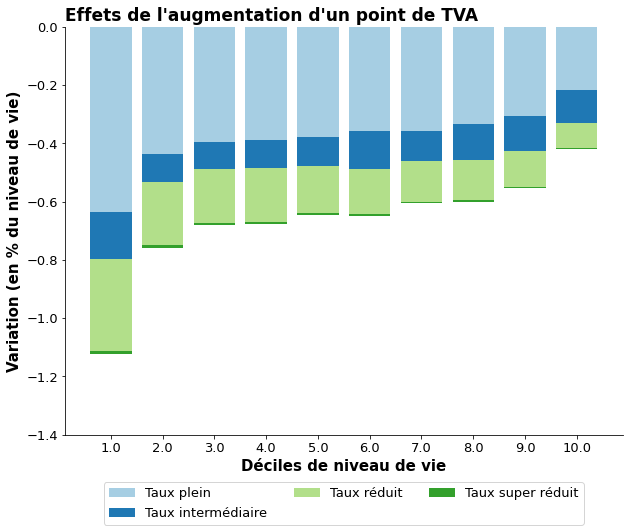

In [39]:
stacked_bar_plot(difference_by_decile, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = False,
                 outfile = 'Taux_effort.pdf',
                #  errors = 'errors'
                 )

#### Décomposition actifs / inactifs

In [ ]:
difference_by_decile_actifs = df_weighted_average_grouped(dataframe = difference_menage.loc[difference_menage['nactifs'] >= 1], 
                                                   groupe = 'decile_indiv_niveau_vie', 
                                                   varlist = ['depenses_tot','depenses_tot_par_uc','depenses_totales_par_uc',
                                                              'rev_disponible','niveau_de_vie'] +
                                                   ['depenses_par_uc_tva_taux_{}'.format(taux) for taux in liste_taux],
                                                   weights = 'pondindiv'
                                                    )
difference_by_decile_actifs['taux_epargne_actifs'] = 1 - difference_by_decile_actifs['depenses_tot'] / difference_by_decile_actifs['rev_disponible']

In [ ]:
difference_by_decile_actifs[['taux_epargne_actifs']]

In [ ]:
for taux in liste_taux:
   difference_by_decile_actifs['Taux_effort_tva_taux_{}'.format(taux)] = difference_by_decile_actifs['depenses_par_uc_tva_taux_{}'.format(taux)] / difference_by_decile_actifs['niveau_de_vie'] * 100
difference_by_decile_actifs['Taux_effort_total'] = difference_by_decile_actifs['depenses_totales_par_uc'] / difference_by_decile_actifs['niveau_de_vie'] * 100

In [ ]:
# Bootstrap 

results_bootstrap_actifs = bootstrap_weighted_mean_by_decile(df.loc[df['nactifs'] >= 1], 'pondindiv', 'decile_indiv_niveau_vie', B = 1000)
errors_actifs = pd.DataFrame(pd.DataFrame(results_bootstrap_actifs).std(axis = 0))
errors_actifs = errors_actifs.reset_index().drop('index',axis = 1).rename({0 : 'std'},axis = 1)
errors_actifs = errors_actifs.reset_index().rename({'index' : 'decile_indiv_niveau_vie'}, axis = 1).set_index('decile_indiv_niveau_vie')
errors_actifs.index = errors_actifs.index + 1
errors_actifs['errors'] = 1.96 * errors_actifs['std']
difference_by_decile_actifs = difference_by_decile_actifs.merge(errors_actifs, left_index = True, right_index = True)

In [ ]:
stacked_bar_plot(difference_by_decile_actifs, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Actifs",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 colors = list(sns.color_palette("Paired")),
                 savefig = False,
                 outfile = 'Taux_effort_actifs_only.pdf',
                #  errors = 'errors'
                )

In [ ]:
difference_by_decile_not_actifs = df_weighted_average_grouped(dataframe = difference_menage.loc[difference_menage['nactifs'] < 1], 
                                                   groupe = 'decile_indiv_niveau_vie', 
                                                   varlist = ['depenses_tot','depenses_tot_par_uc','depenses_totales_par_uc',
                                                              'rev_disponible','niveau_de_vie'] +
                                                   ['depenses_par_uc_tva_taux_{}'.format(taux) for taux in liste_taux],
                                                   weights= 'pondindiv'
                                                    )
difference_by_decile_not_actifs['taux_epargne_inactifs'] = 1 - difference_by_decile_not_actifs['depenses_tot'] / difference_by_decile_not_actifs['rev_disponible']

In [ ]:
difference_by_decile_not_actifs[['taux_epargne_inactifs']]

In [ ]:
for taux in liste_taux:
   difference_by_decile_not_actifs['Taux_effort_tva_taux_{}'.format(taux)] = difference_by_decile_not_actifs['depenses_par_uc_tva_taux_{}'.format(taux)] / difference_by_decile_not_actifs['niveau_de_vie'] * 100
difference_by_decile_not_actifs['Taux_effort_total'] = difference_by_decile_not_actifs['depenses_totales_par_uc'] / difference_by_decile_not_actifs['niveau_de_vie'] * 100

In [ ]:
# Bootstrap 

results_bootstrap_inactifs = bootstrap_weighted_mean_by_decile(df.loc[df['actifs'] < 1], 'pondindiv', 'decile_indiv_niveau_vie', B = 1000)
errors_inactifs = pd.DataFrame(pd.DataFrame(results_bootstrap_inactifs).std(axis = 0))
errors_inactifs = errors_inactifs.reset_index().drop('index',axis = 1).rename({0 : 'std'},axis = 1)
errors_inactifs = errors_inactifs.reset_index().rename({'index' : 'decile_indiv_niveau_vie'}, axis = 1).set_index('decile_indiv_niveau_vie')
errors_inactifs.index = errors_inactifs.index + 1
errors_inactifs['errors'] = 1.96 * errors_inactifs['std']
difference_by_decile_not_actifs = difference_by_decile_not_actifs.merge(errors_inactifs, left_index = True, right_index = True)

In [ ]:
stacked_bar_plot(difference_by_decile_not_actifs, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Inactifs",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 colors = list(sns.color_palette("Paired")),
                 savefig = False,
                 outfile = 'Taux_effort_not_actifs.pdf',
                #  errors = 'errors'
                 )

In [ ]:
double_stacked_bar_plot(difference_by_decile_not_actifs,
                        difference_by_decile_actifs, 
                        variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                        labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                        title1 = "Effets d'un point de TVA - Inactifs",
                        title2 = "Effets d'un point de TVA - Actifs",
                        xlabel = 'Déciles de niveau de vie' ,
                        ylabel = 'Variation (en % du niveau de vie)',
                        colors = list(sns.color_palette("Paired")),
                        savefig = False,
                        outfile = 'Taux_effort_actifs_not_actifs.pdf')

### Autre décomposition

In [ ]:
[ 'situapr',
 'situaagr',
 'nactifs',
 'npers',
 'nadultes',
 'nenfants',
 'identifiant_menage']

### Situation professionnel de la personne ref (1: emploi et apprenti , 2: Chomeur, etudiant, inactifs, 3: retraités)

In [ ]:
difference_menage['cat_pro_menage'] = 3
difference_menage.loc[
    (difference_menage['situapr'] == 1) | (difference_menage['situacj'] == 1), 'cat_pro_menage',] = 1
difference_menage.loc[
    ((difference_menage['situapr'] == 5) & (difference_menage['situacj'] != 1)) | 
    ((difference_menage['situapr'] != 1) & (difference_menage['situacj'] == 5)), 'cat_pro_menage',] = 2    

difference_menage['cat_pro_menage'].value_counts()
# difference_menage.groupby(['decile_indiv_niveau_vie','cat_pro_menage'])['identifiant_menage'].count() 

In [10]:
from openfisca_france_indirect_taxation.Calage_consommation_bdf import get_inflators

In [11]:
inflators = get_inflators(target_year = 2025, data_year = 2017)

In [12]:
inflators

{'depenses_carburants': 1.5424368990566797,
 'depenses_diesel': 1.5424368990566797,
 'depenses_essence': 1.5424368990566797,
 'loyer_impute': 1.6792885937575115,
 'poste_01_1_1_1': 1.5778943184904892,
 'poste_01_1_1_2': 1.5778943184904892,
 'poste_01_1_1_3': 1.5778943184904892,
 'poste_01_1_1_4': 1.5778943184904892,
 'poste_01_1_1_5': 1.5778943184904892,
 'poste_01_1_2_1': 1.2077745982446135,
 'poste_01_1_2_2': 1.2077745982446135,
 'poste_01_1_2_3': 1.2077745982446135,
 'poste_01_1_2_4': 1.2077745982446135,
 'poste_01_1_2_5': 1.2077745982446135,
 'poste_01_1_2_6': 1.2077745982446135,
 'poste_01_1_2_7': 1.2077745982446135,
 'poste_01_1_3_0': 0.8573294106078873,
 'poste_01_1_3_1': 0.8573294106078873,
 'poste_01_1_3_2': 0.8573294106078873,
 'poste_01_1_3_3': 0.8573294106078873,
 'poste_01_1_3_4': 0.8573294106078873,
 'poste_01_1_4_1': 1.5468485409956694,
 'poste_01_1_4_2': 1.5468485409956694,
 'poste_01_1_4_3': 1.5468485409956694,
 'poste_01_1_4_4': 1.5468485409956694,
 'poste_01_1_4_5': 

### Type de ménage 
1: célibataire sans enfants 2: celibataire avec enfant 3: couple sans enfant 4: couple avec enfant

In [17]:
difference_menage['cat_famille_menage'] = pd.NA

difference_menage.loc[
    (difference_menage['nadultes'] == 1) & (difference_menage['nenfants'] == 0),
    'cat_famille_menage',] = 1
difference_menage.loc[
    (difference_menage['nadultes'] == 1) & (difference_menage['nenfants'] > 0),
    'cat_famille_menage',] = 2
difference_menage.loc[
    (difference_menage['nadultes'] >= 2) & (difference_menage['nenfants'] == 0),
    'cat_famille_menage',] = 3
difference_menage.loc[
    (difference_menage['nadultes'] >= 2) & (difference_menage['nenfants'] > 0),
    'cat_famille_menage',] = 4

# difference_menage['cat_famille_menage'].value_counts(dropna=False)

In [40]:
difference_menage.groupby(['decile_indiv_niveau_vie','cat_famille_menage'])['identifiant_menage'].count()

decile_indiv_niveau_vie  cat_famille_menage
1.0                      1                     416
                         2                     399
                         3                     141
                         4                     271
2.0                      1                     402
                         2                     307
                         3                     197
                         4                     320
3.0                      1                     414
                         2                     317
                         3                     259
                         4                     301
4.0                      1                     389
                         2                     194
                         3                     318
                         4                     337
5.0                      1                     385
                         2                     169
                         3            

In [41]:
difference_menage.loc[difference_menage['cat_famille_menage'] == 2].sort_values(by = 'depenses_par_uc_tva_taux_intermediaire')[['identifiant_menage', 'depenses_tva_taux_intermediaire']]


,identifiant_menage,depenses_tva_taux_intermediaire
3557,201703564,-4152.812500
10645,201710674,-2735.968750
11709,201711741,-1606.562500
10450,201710479,-1259.890625
4654,201704665,-957.226562
...,...,...
1052,201701053,0.000000
7173,201707192,0.000000
7355,201707374,0.000000
9351,201709377,0.000000


In [42]:
baseline_menage.loc[baseline_menage['identifiant_menage'] == 201703564, ['rev_disponible','depenses_tva_taux_intermediaire','depenses_tot','depenses_totales']]

,rev_disponible,depenses_tva_taux_intermediaire,depenses_tot,depenses_totales
3557,39582.1875,456807.34375,506643.96875,498265.90625


In [43]:
baseline_menage.loc[baseline_menage['identifiant_menage'] == 201710674]

,npers,depenses_tva_taux_intermediaire,situapr,depenses_totales,niveau_vie_decile,nadultes,depenses_tva_taux_reduit,depenses_ht_tva_taux_intermediaire,depenses_tva_taux_plein,depenses_tot,...,nactifs,depenses_tva_taux_super_reduit,decile_indiv_niveau_vie,situacj,situaagr,nenfants,niveau_de_vie,depenses_ht_tva_taux_super_reduit,pondmen,rev_disponible > 0
10645,2,300954.84375,1.0,314616.78125,6.0,1,3741.131592,273595.3125,9920.827148,316188.8125,...,1,0.0,6.0,NaN,NaN,1,28109.257812,0.0,3190,True


In [44]:
from openfisca_france_indirect_taxation.variables.consommation.categories_fiscales import get_legislation_data_frames
from openfisca_france_indirect_taxation.Calage_consommation_bdf import format_poste

In [45]:
bdf_legislation = get_legislation_data_frames()

In [53]:
bdf_legislation.loc[bdf_legislation['adjusted_bdf'].str.startswith('04.3')]

,Label_division,Label_groupe,Label_classe,Label_sous_classe,Code_sous_classe,code_bdf,adjusted_bdf,start,stop,origin,categorie_fiscale
90,"logement, eau, gaz, electricite et autres comb...",travaux courants d’entretien et de réparation ...,travaux),Produits destinés aux travaux courants d’entre...,4311,04.3.1.1,04.3.1.1,1994,2024,BDF,tva_taux_plein
91,"logement, eau, gaz, electricite et autres comb...",travaux courants d’entretien et de réparation ...,services d'entretien et petites réparation dan...,Services d'entretien et petites réparation dan...,4321,04.3.2.1,04.3.2.1,1994,2024,BDF,tva_taux_intermediaire


In [46]:
liste_taux_intermediaire =bdf_legislation.loc[bdf_legislation['categorie_fiscale'] == 'tva_taux_intermediaire','adjusted_bdf'].tolist()
liste_postes_inter = [ f"poste_{poste[:2]}_{poste[3]}_{poste[5]}_{poste[7]}" for poste in liste_taux_intermediaire]

In [47]:
input_bdf.loc[input_bdf['identifiant_menage'] == 201703564, list(set(input_bdf.columns).intersection(set(liste_postes_inter)))]

,poste_09_6_1_1,poste_11_2_1_1,poste_04_3_2_1,poste_07_3_2_1,poste_04_4_2_1,poste_09_6_9_1,poste_04_5_4_1,poste_09_3_1_1,poste_09_6_1_2,poste_11_1_1_1,poste_09_4_2_2,poste_07_3_3_1,poste_13_3_1_1,poste_05_6_2_1,poste_07_3_4_1,poste_07_3_1_1,poste_07_3_5_1
3557,837.2,0.0,77901.2,0.0,0,137.0,0.0,0.0,0.0,3198.0,480.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
baseline_test= survey_scenario.create_data_frame_by_entity(['identifiant_menage'] + liste_postes_inter, filter_by = 'rev_disponible > 0', use_baseline = True, period = year)['menage']

In [49]:
baseline_test.loc[baseline_test['identifiant_menage'] == 201703564].sum(axis = 0)

poste_11_1_1_1         8784.387695
poste_04_3_2_1        447274.09375
poste_07_3_2_1                 0.0
poste_04_4_3_1                 0.0
poste_09_4_2_2          741.852051
poste_07_3_3_1                 0.0
poste_07_3_5_1                 0.0
poste_04_4_2_1                 0.0
poste_07_3_4_1                 0.0
poste_07_3_1_1                 0.0
poste_09_6_1_1         2068.744141
poste_11_2_1_1                 0.0
identifiant_menage       201703564
poste_09_6_1_2                 0.0
rev_disponible          39582.1875
poste_13_3_1_1                 0.0
poste_05_6_2_1                 0.0
poste_09_6_9_1            7.022909
poste_04_5_4_1                 0.0
poste_09_3_1_1                 0.0
rev_disponible > 0               1
dtype: object

In [ ]:
input_bdf.loc[input_bdf['poste_04_3_2_1'] != 0, ['poste_04_3_2_1']].sort_values(by = 'poste_04_3_2_1', ascending = False)

In [ ]:
inflators_2025 

In [ ]:
inflators_2025.get('poste_04_3_1_1')

In [ ]:
input_bdf.loc[input_bdf['poste_04_3_1_1'] != 0]

In [ ]:
bdf_legislation.loc[bdf_legislation['adjusted_bdf'].str.startswith('04')]

In [18]:
def effect_by_decile(df):
   difference_by_decile = df_weighted_average_grouped(dataframe = df, 
                                                      groupe = 'decile_indiv_niveau_vie', 
                                                      varlist = ['depenses_tot','depenses_tot_par_uc','depenses_totales_par_uc',
                                                               'rev_disponible','niveau_de_vie'] +
                                                      ['depenses_par_uc_tva_taux_{}'.format(taux) for taux in liste_taux],
                                                      weights = 'pondindiv'
                                                      )

   for taux in liste_taux:
      difference_by_decile['Taux_effort_tva_taux_{}'.format(taux)] = difference_by_decile['depenses_par_uc_tva_taux_{}'.format(taux)] / difference_by_decile['niveau_de_vie'] * 100
   difference_by_decile['Taux_effort_total'] = difference_by_decile['depenses_totales_par_uc'] / difference_by_decile['niveau_de_vie'] * 100
   return(difference_by_decile)


In [19]:
df_famille_1 = difference_menage.loc[difference_menage['cat_famille_menage'] == 1]
df_by_decile_famille_1 = effect_by_decile(df_famille_1)
df_famille_2 = difference_menage.loc[difference_menage['cat_famille_menage'] == 2]
df_by_decile_famille_2 = effect_by_decile(df_famille_2)
df_famille_3 = difference_menage.loc[difference_menage['cat_famille_menage'] == 3]
df_by_decile_famille_3 = effect_by_decile(df_famille_3)
df_famille_4 = difference_menage.loc[difference_menage['cat_famille_menage'] == 4]
df_by_decile_famille_4 = effect_by_decile(df_famille_4)

In [ ]:
df_famille_2.groupby('decile_indiv_niveau_vie')['depenses_tva_taux_intermediaire'].sum()

In [ ]:
df_famille_2.loc[:,['decile_indiv_niveau_vie','depenses_tva_taux_intermediaire']].sort_values(by = 'depenses_tva_taux_intermediaire', ascending = False)

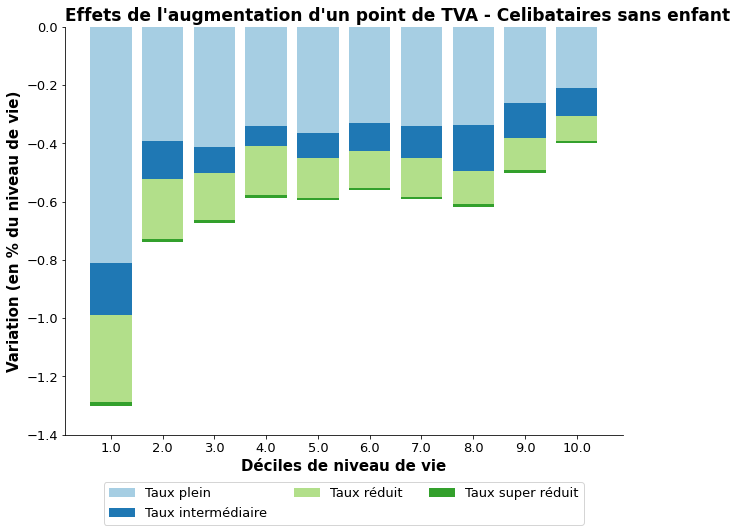

In [24]:
stacked_bar_plot(df_by_decile_famille_1, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Celibataires sans enfant",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 outfile = 'Taux_effort_celib_no_kids.pdf',
                 output_path = output_path,
                #  errors = 'errors'
                )

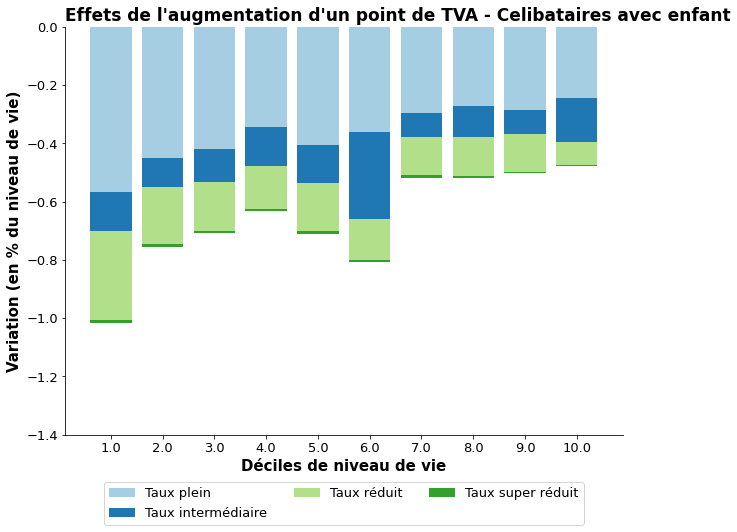

In [26]:
stacked_bar_plot(df_by_decile_famille_2, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Celibataires avec enfant",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path,
                 outfile = 'Taux_effort_celib_with_kids.pdf',
                #  errors = 'errors'
                )

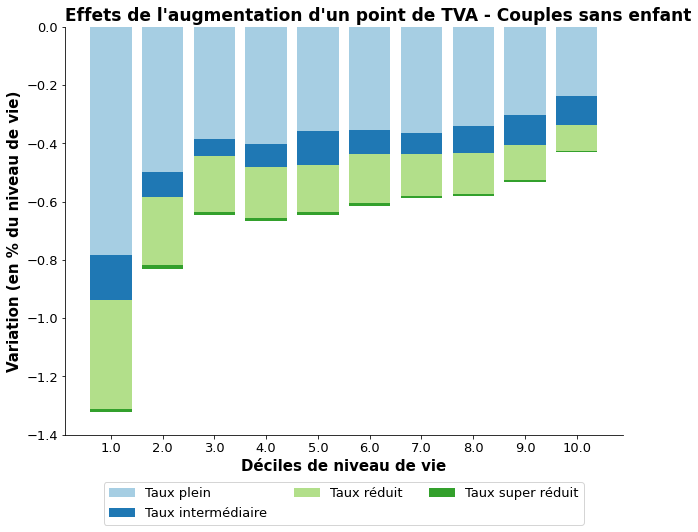

In [27]:
stacked_bar_plot(df_by_decile_famille_3, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Couples sans enfant",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path,
                 outfile = 'Taux_effort_couples_no_kids.pdf',
                #  errors = 'errors'
                )

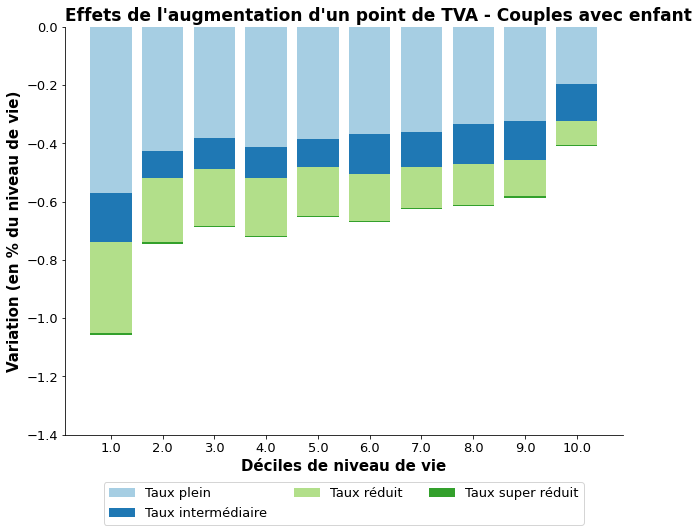

In [28]:
stacked_bar_plot(df_by_decile_famille_4, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - Couples avec enfant",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 output_path = output_path,
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 outfile = 'Taux_effort_couples_with_kids.pdf',
                #  errors = 'errors'
                )

### Catégorie d'age du responsable du ménage

In [29]:
difference_menage["categorie_age"] = pd.cut(
    difference_menage["agepr"],
    bins=[18, 35, 50, 65, float("inf")],
    labels=["18-34", "35-49", "50-64", "65+"],
    right=False,
)

difference_menage["categorie_age"].value_counts(sort=False, dropna=False)

categorie_age
18-34    1827
35-49    3510
50-64    3426
65+      3281
NaN         4
Name: count, dtype: int64

In [ ]:
difference_menage.groupby(['decile_indiv_niveau_vie','categorie_age'])['identifiant_menage'].count()

In [30]:
df_age_1 = difference_menage.loc[difference_menage['categorie_age'] == "18-34"]
df_by_decile_age_1 = effect_by_decile(df_age_1)
df_age_2 = difference_menage.loc[difference_menage['categorie_age'] == "35-49"]
df_by_decile_age_2 = effect_by_decile(df_age_2)
df_age_3 = difference_menage.loc[difference_menage['categorie_age'] == "50-64"]
df_by_decile_age_3 = effect_by_decile(df_age_3)
df_age_4 = difference_menage.loc[difference_menage['categorie_age'] == "65+"]
df_by_decile_age_4 = effect_by_decile(df_age_4)   

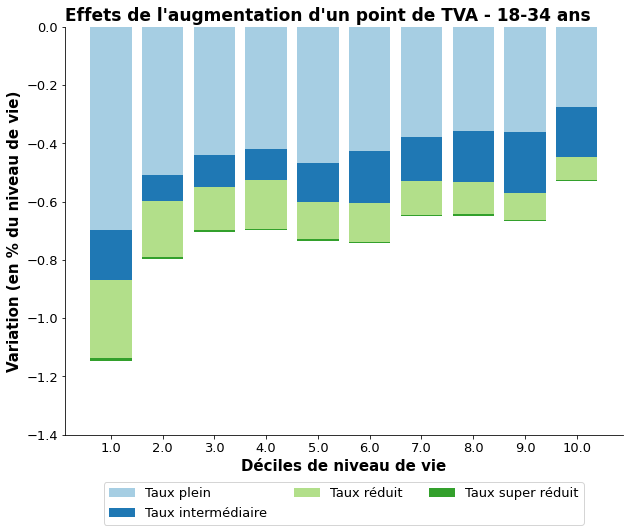

In [31]:
stacked_bar_plot(df_by_decile_age_1, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - 18-34 ans",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path,
                 outfile = 'Taux_effort_age_18_34.pdf',
                #  errors = 'errors'
                )

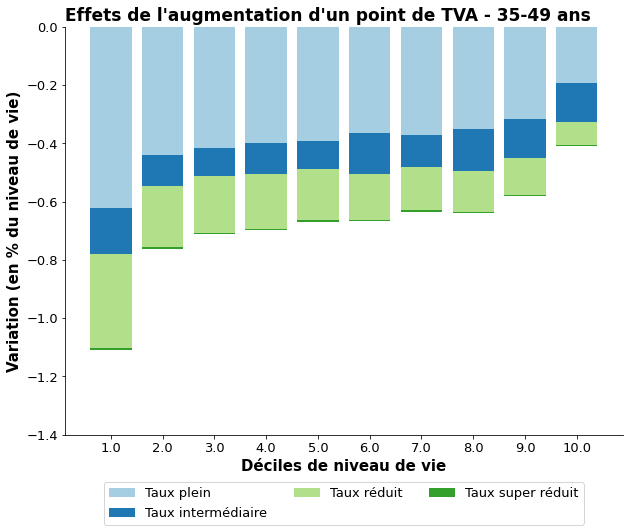

In [32]:
stacked_bar_plot(df_by_decile_age_2, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - 35-49 ans",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path,
                 outfile = 'Taux_effort_age_35_49.pdf',
                #  errors = 'errors'
                )

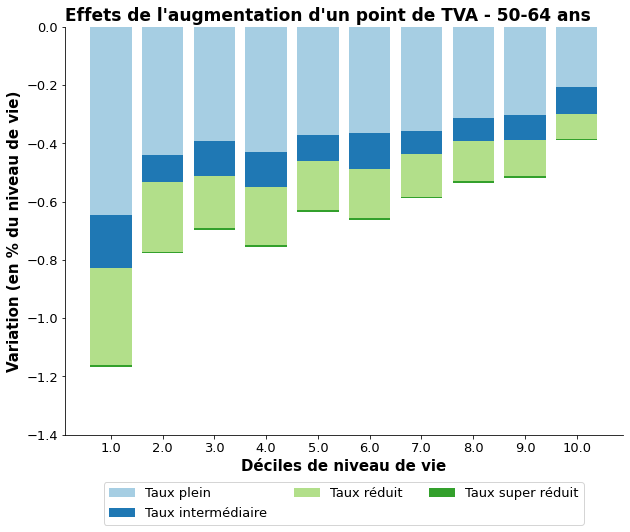

In [33]:
stacked_bar_plot(df_by_decile_age_3, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - 50-64 ans",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim = (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path, 
                 outfile = 'Taux_effort_age_50_64.pdf',
                #  errors = 'errors'
                )

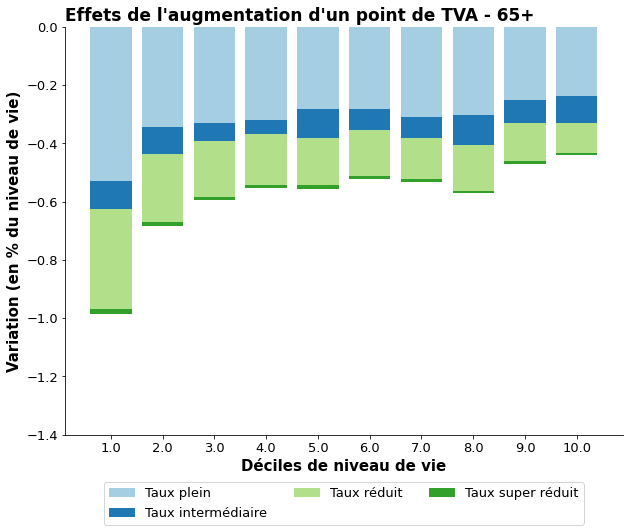

In [34]:
stacked_bar_plot(df_by_decile_age_4, 
                 variables = ['Taux_effort_tva_taux_{}'.format(taux) for taux in liste_taux],
                 labels = ['Taux plein','Taux intermédiaire','Taux réduit','Taux super réduit'],
                 title = "Effets de l'augmentation d'un point de TVA - 65+",
                 xlabel = 'Déciles de niveau de vie' ,
                 ylabel ='Variation (en % du niveau de vie)',
                 ylim= (-1.4, 0),
                 colors = list(sns.color_palette("Paired")),
                 savefig = True,
                 output_path = output_path,
                 outfile = 'Taux_effort_age_65_plus.pdf',
                #  errors = 'errors'
                )

In [35]:
df_by_decile_age_1['Taux_effort_total']

decile_indiv_niveau_vie
1.0    -1.146854
2.0    -0.796760
3.0    -0.703663
4.0    -0.697967
5.0    -0.733762
6.0    -0.743362
7.0    -0.650944
8.0    -0.648872
9.0    -0.668106
10.0   -0.527351
Name: Taux_effort_total, dtype: float64

In [36]:
df_by_decile_age_2['Taux_effort_total']

decile_indiv_niveau_vie
1.0    -1.109386
2.0    -0.760950
3.0    -0.711460
4.0    -0.697458
5.0    -0.669407
6.0    -0.667176
7.0    -0.633981
8.0    -0.639003
9.0    -0.580771
10.0   -0.409728
Name: Taux_effort_total, dtype: float64

In [37]:
df_by_decile_age_3['Taux_effort_total']

decile_indiv_niveau_vie
1.0    -1.169059
2.0    -0.777877
3.0    -0.695819
4.0    -0.754742
5.0    -0.634425
6.0    -0.662481
7.0    -0.588388
8.0    -0.535748
9.0    -0.519831
10.0   -0.386682
Name: Taux_effort_total, dtype: float64

In [38]:
df_by_decile_age_4['Taux_effort_total']

decile_indiv_niveau_vie
1.0    -0.985110
2.0    -0.684267
3.0    -0.594748
4.0    -0.554807
5.0    -0.556179
6.0    -0.522939
7.0    -0.531860
8.0    -0.570904
9.0    -0.470414
10.0   -0.441053
Name: Taux_effort_total, dtype: float64